This jupyter notebook is prepared by Sejal Mogalgiddi

###Load Data and perform general EDA

In [ ]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import scipy.stats as st
from sklearn import ensemble, tree, linear_model
import missingno as msno

In [ ]:
df= pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ecommarce.csv')
rows,cols=df.shape
print(f"number of rows: {rows}")
print(f"number of columns: {cols}")

number of rows: 500
number of columns: 9


In [ ]:
df.head()

,Unnamed: 0,Email,Address,Credit Card,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,0,adkv@ota.com,"89280 Mark Lane\nNew John, MN 16131",3544288738428794,35.497268,13.655651,40.577668,4.582621,588.951054
1,1,gjun@syj.com,"363 Amanda Cliff Apt. 638\nWest Angela, KS 31437",6546228325389133,32.926272,12.109461,38.268959,3.164034,393.204933
2,2,qjyr@pkk.com,"62008 Adam Lodge\nLake Pamela, NY 30677",4406395951712628314,34.000915,12.330278,38.110597,4.604543,488.547505
3,3,jkiu@xsb.com,"950 Tami Island\nLake Aimeeview, MT 93614",30334036663133,35.305557,14.717514,37.721283,3.620179,582.852344
4,4,stvb@niy.com,"08254 Kelly Squares\nNorth Lauren, AR 78382",3582080469154498,34.330673,13.795189,38.536653,4.946308,600.406092


In [ ]:
df.tail()

,Unnamed: 0,Email,Address,Credit Card,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
495,495,xskz@gwj.com,"7083 Wallace Rest\nNew Trevor, NM 70240",30206742023085,34.237660,14.566160,37.417985,4.246573,574.847438
496,496,awrc@iok.com,"663 Christopher Garden\nLake Carrieberg, PA 70796",6011536844623717,35.702529,12.695736,38.190268,4.076526,530.049004
497,497,pndt@jyr.com,"1555 Chen Road\nBergerchester, NH 46418",4086276267550896697,33.646777,12.499409,39.332576,5.458264,552.620145
498,498,zvtz@onj.com,"5568 Robert Station Apt. 030\nTurnerstad, GA 9...",36218092488069,34.322501,13.391423,37.840086,2.836485,457.469510
499,499,phqb@nlg.com,"424 Mark Junctions\nDarrellchester, TX 09088",5427200269739116,34.715981,13.418808,36.771016,3.235160,498.778642


In [ ]:
#call the describe method of dataframe to see some summary statistics of the numerical columns.
df.describe()

,Unnamed: 0,Credit Card,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,5.000000e+02,500.000000,500.000000,500.000000,500.000000,500.000000
mean,249.500000,3.706324e+17,34.053194,13.052488,38.060445,4.033462,500.314038
std,144.481833,1.235588e+18,0.992563,0.994216,1.010489,0.999278,79.314782
min,0.000000,5.018057e+11,30.532429,9.508152,34.913847,0.769901,257.670582
25%,124.750000,3.683275e+13,33.341822,12.388153,37.349257,3.430450,446.038277
50%,249.500000,3.513612e+15,34.082008,12.983231,38.069367,4.033975,499.887875
75%,374.250000,4.777131e+15,34.711985,13.753850,38.716432,4.626502,550.313828
max,499.000000,4.959148e+18,37.139662,16.126994,41.005182,7.422689,766.518462


###Explain in words about the description of any two variables

In the Column Yearly Amount Spent we can see a few important details, we see that the minimum is \$257.67 spent and the maximum is \$766.52. This wide range shows a variety in spending and how large the customer spending range is. The standard deviation lies at \$79.13, this hints at the fact that there is some moderate variability in how much Customers tend to spend in a year.

In the "time spent on website" column, we can see that the minimum time a customer spent is 34.9 minutes, while the maximum is 41 minutes. After looking at our mean (38.06 minutes), we can see that customers spend an average of 38 minutes browsing the website. We see that the standard deviation is 1.01, which indicates very low variability. This further supports that customers spend around 38 minutes on the website.

In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
Email,0
Address,0
Credit Card,0
Avg. Session Length,0
Time on App,0
Time on Website,0
Length of Membership,0
Yearly Amount Spent,0


We can see that there are no missing values that show when we do a missing analysis. This suggests that our dataset is clean and doesn't need any imputation/removal of missing data before further analysis.

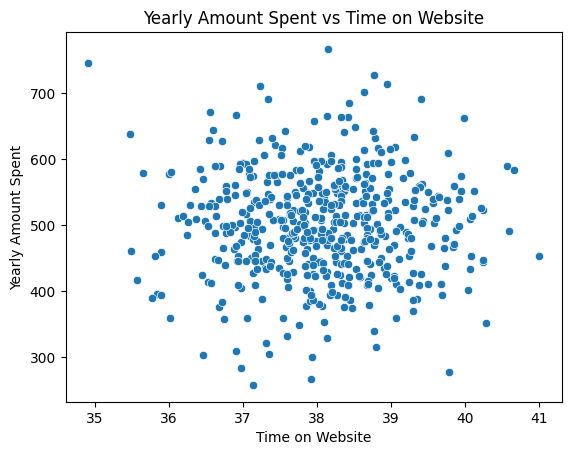

In [ ]:
sns.scatterplot(x='Time on Website', y='Yearly Amount Spent', data=df)
plt.title("Yearly Amount Spent vs Time on Website")
plt.show()

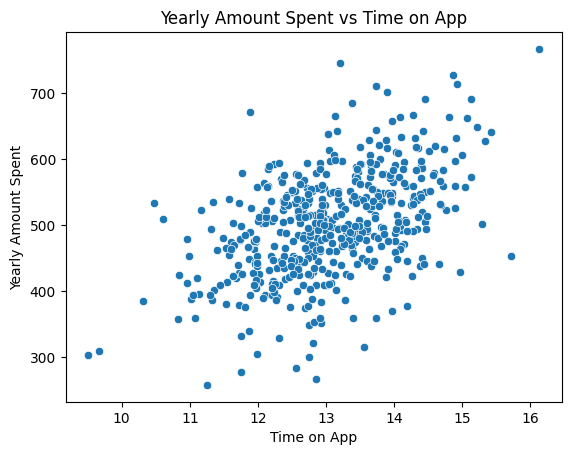

In [ ]:
sns.scatterplot(x='Time on App', y='Yearly Amount Spent', data=df)
plt.title("Yearly Amount Spent vs Time on App")
plt.show()

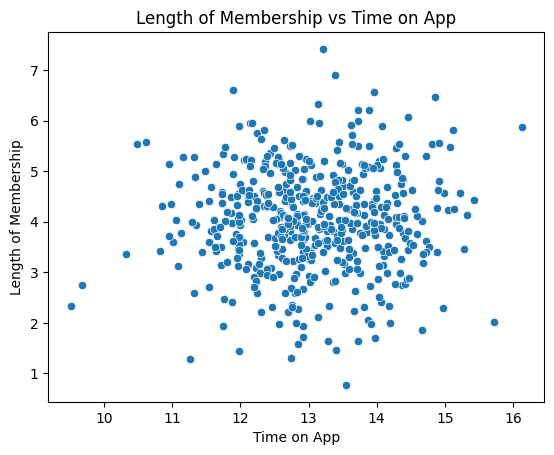

In [ ]:
sns.scatterplot(x='Time on App', y='Length of Membership', data=df)
plt.title("Length of Membership vs Time on App")
plt.show()

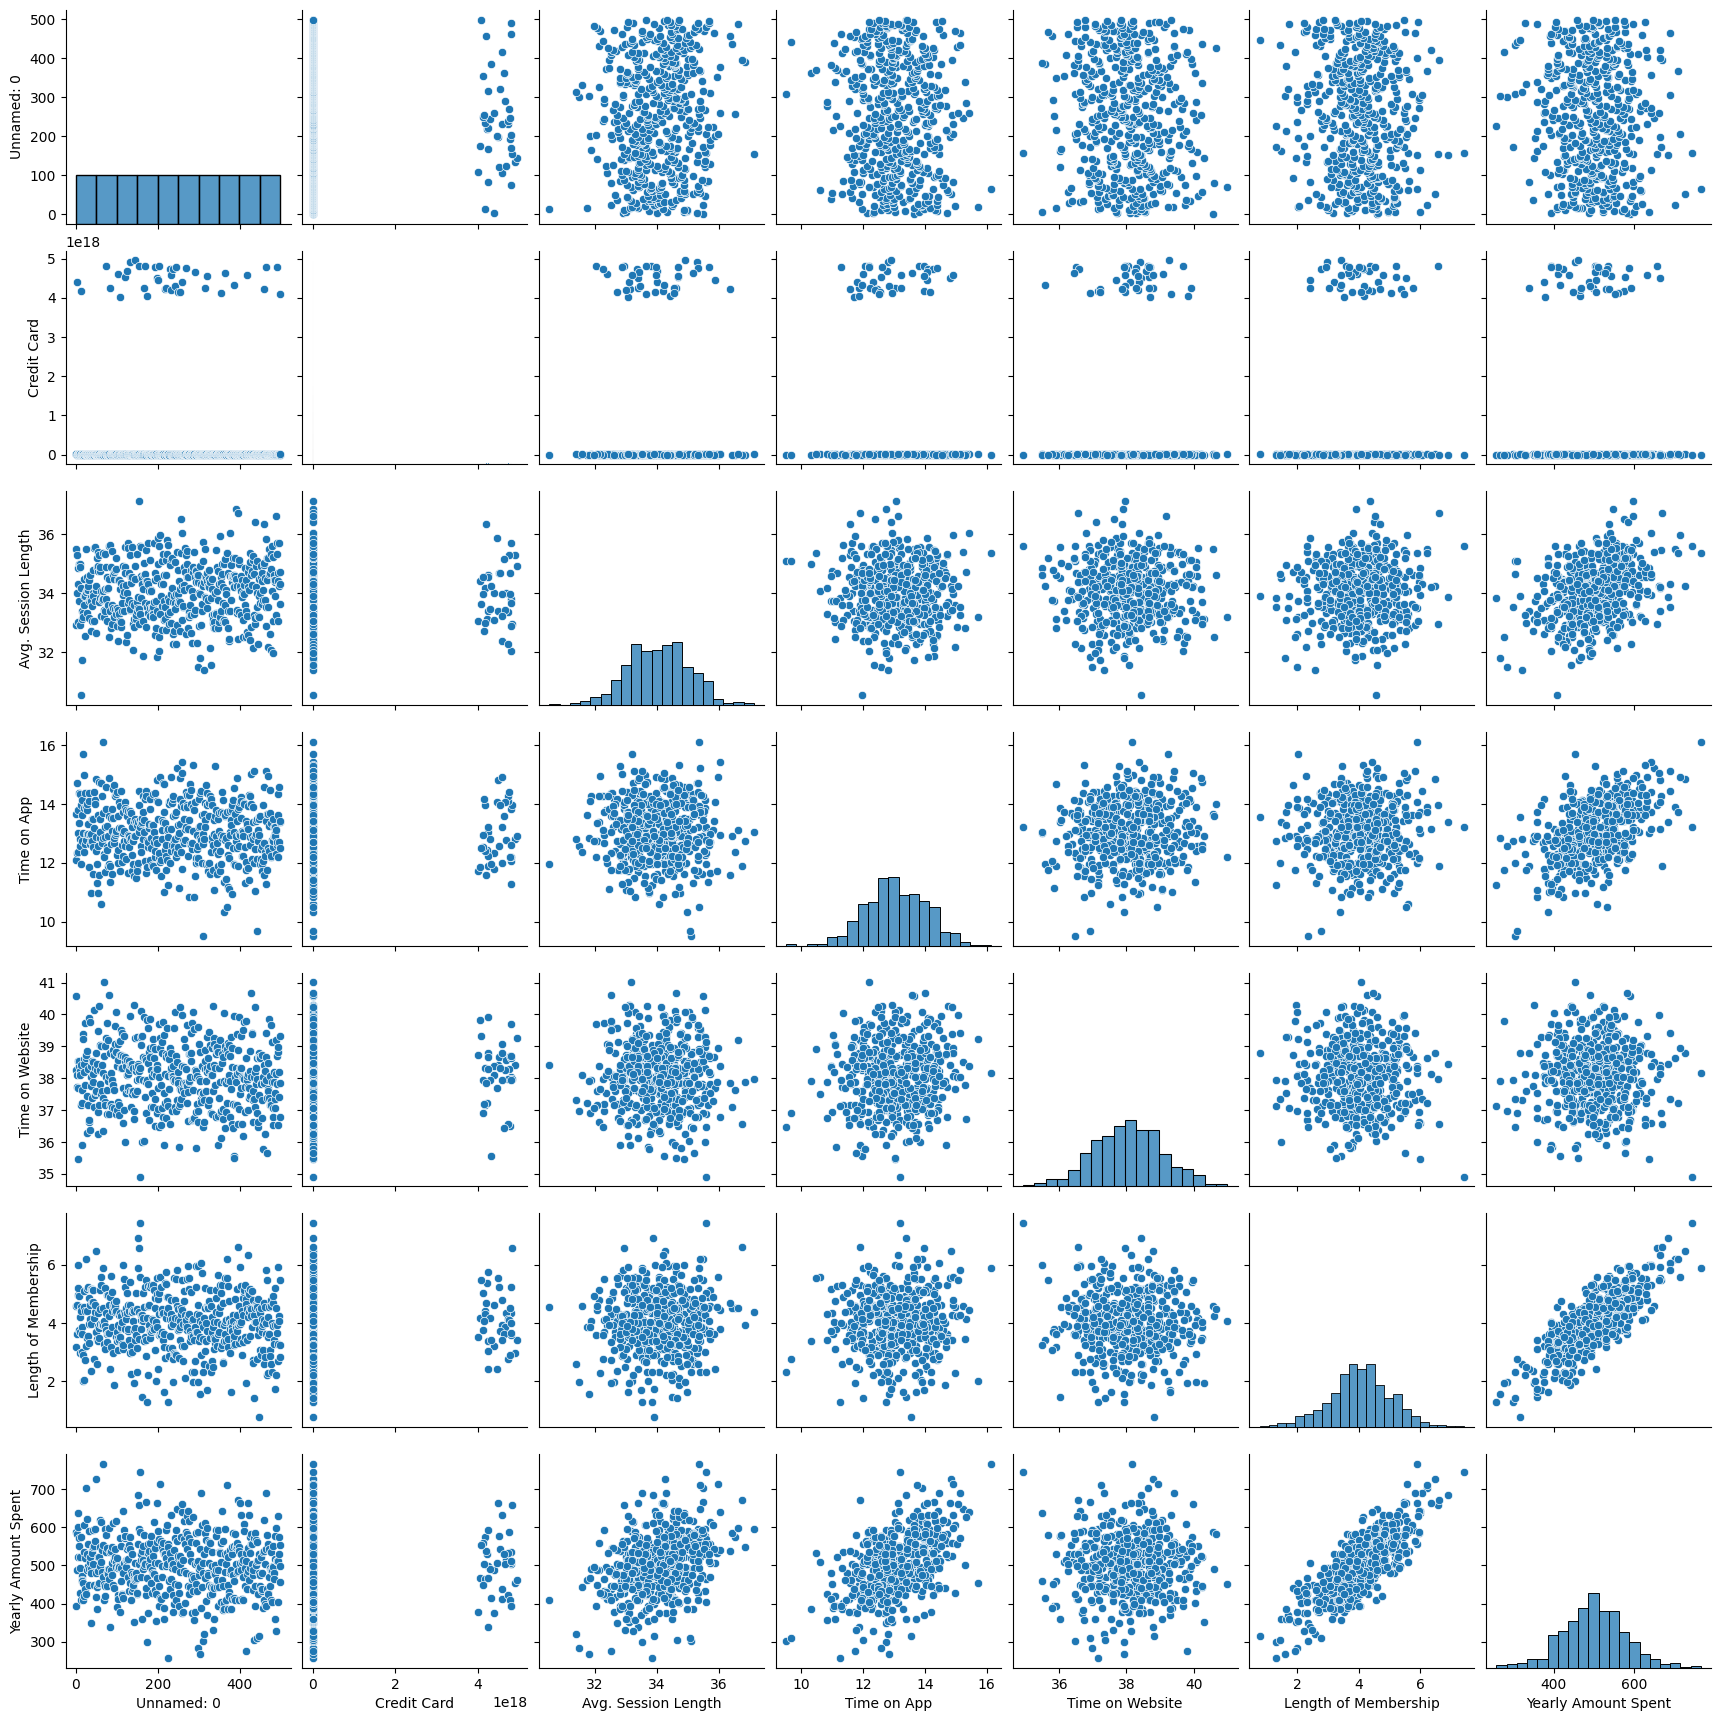

In [ ]:
sns.pairplot(df)
plt.show()

Based on the plots, what feature is mostly correlated with the yearly amount spent?

From these plots we can see that the length of membership is the most lineraly correalted with Yearly amount spent. We make this conclusion because we see a clear positive linear trend in the plot where the points increase together.

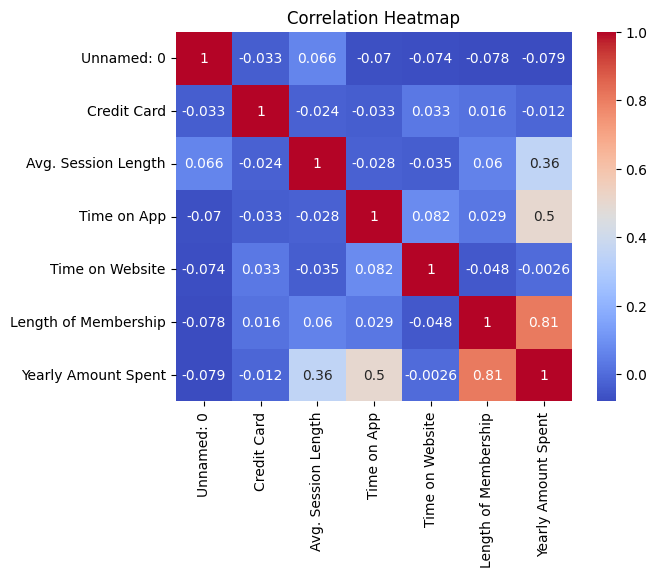

In [ ]:
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Which columns must be removed based on that and which column is mostly interesting and related to Yearly Amount Spent?

In this heatmap we see a few interesting correlations, the one that stands out the most is the correlation between Yearly amount spent and the length of membership, we see a correlation of 0.81 which means the trends follows this pattern: Length of Membership increases Yearly amount spent also increases.

We should remove the columns Unnamed: 0, credit card, and Time on Website (however this will remain in the dataset as per instructions) as they have a correlation of-0.079,-0.012 and-0.0026 respectively. These low negative values indicate that there is little to no correlation. The variables provide no meaningful insight and Unnamed:0 seems to be a index column.

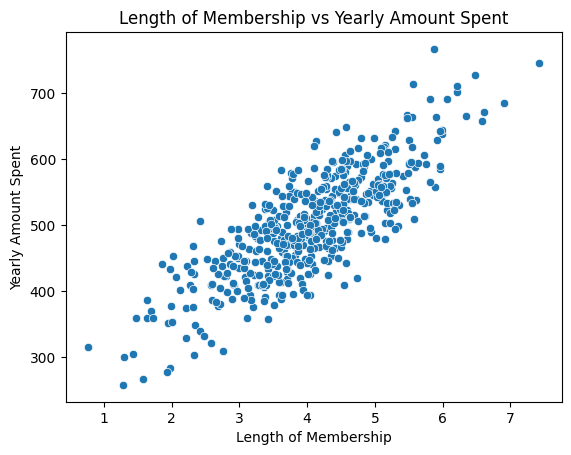

In [ ]:
sns.scatterplot(x='Length of Membership', y='Yearly Amount Spent', data=df)
plt.title("Length of Membership vs Yearly Amount Spent")
plt.show()

###Feature Selection and Pre-processing
We are going to remove Unnamed: 0 and credit card from previous analysis but I have also decided to remove Address and Email as they are perosnal identifiers and dont really provide insight into our data. In the future analysis if we need to created dummy variable or dummy variable for these variables we would get a lot of unnecessay noise and might lead to overfitting or underfitting. To prevent this early on we should remove it now.

In [ ]:
df = df.drop(['Unnamed: 0', 'Email', 'Address', 'Credit Card'], axis=1)

###X/Y and Training/Test Split

In [ ]:
from sklearn.model_selection import train_test_split
X = df.drop('Yearly Amount Spent', axis=1)
y = df['Yearly Amount Spent']
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=101
)

In [ ]:
#just a check to see # of rows in each set

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(350, 4)
(150, 4)
(350,)
(150,)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

###Training Linear Model using SKLearn's LinearRegression

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
print("Intercept:", lr.intercept_)
print("Coefficiants:", lr.coef_)


Intercept: 499.7231164913073
Coefficiants: [26.04265125 36.67425683  0.18503853 60.20236045]


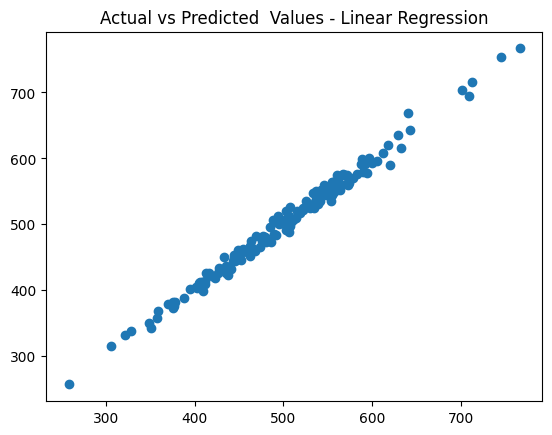

In [ ]:
y_pred=lr.predict(X_test_scaled)
plt.scatter(y_test, y_pred)
plt.title("Actual vs Predicted  Values - Linear Regression")
plt.show()

In [ ]:
from sklearn import metrics

print("MAE:",  metrics.mean_absolute_error(y_test,y_pred))
print("MSE:",  metrics.mean_squared_error(y_test,y_pred))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print("R^2:", metrics.r2_score(y_test, y_pred))

MAE: 7.228148653430841
MSE: 79.8130516509744
RMSE: 8.933815066978632
R^2: 0.9890046246741234


###Interpret the coefficient and which coefficient belongs to which feature and based on that explain any strategy that should help the business

Based on the coefficients we found earlier, we can see that the relationship between each feature and yearly spending is reflected in the magnitude of its coefficient. Features that have large positive coefficients will have a stronger impact on spending. As the features increase, yearly spending will also increase because the coefficients are positive. Features with larger coefficients (e.g., Length of Membership) result in more significant increases in spending compared to other features. This suggests that customers who remain members with the company will tend to spend more each year. We also see Time on App displaying a strong positive relationship, where users who use the app more tend to spend more. Overall, we see that the user's average session length has a noticeable effect on how much a user spends on products, whereas Time on Website does not have much of an effect on how much users spend on products.

##Helping the Business

Based on the results we saw and concluded, the company should prioritize the app, as more people spend a lot of time on the app versus the website. The company should try to find ways to make the app more appealing, such as implementing loyalty programs or other strategies that will increase customer's Membership Length. The company will benefit more from investing in and improving the mobile app experience for their users rather than focusing on the website.

### Normal Equation

In [ ]:
X_train_np = X_train.to_numpy()
y_train_np = y_train.to_numpy()

ones=np.ones((X_train_np.shape[0], 1))
X_train_np=np.hstack((ones, X_train_np))

theta_best = np.linalg.inv (X_train_np.T @ X_train_np) @ X_train_np.T @ y_train_np

print("Best theta values:")
print(theta_best)

Best theta values:
[-1.14233444e+03  2.59815497e+01  3.85901588e+01  1.90405278e-01
  6.12790965e+01]


In [ ]:
lm_un=LinearRegression()
lm_un.fit(X_train, y_train)

print("Unscaled Intercept:", lm_un.intercept_)
print("Unscaled Coefficients", lm_un.coef_)

Unscaled Intercept: -1142.3344442767705
Unscaled Coefficients [25.98154972 38.59015875  0.19040528 61.27909654]


We found the best theta values to be: -1.14233444e+03,  2.59815497e+01, 3.85901588e+01, 1.90405278e-01, 6.12790965e+01 and we got similar values when we obtained coefficients obtained from sklearns's LinearRegression model trained on the unscaled data. This confirms that the normal equation was implemented correctly and all the small differences we may find come from numerical precision.

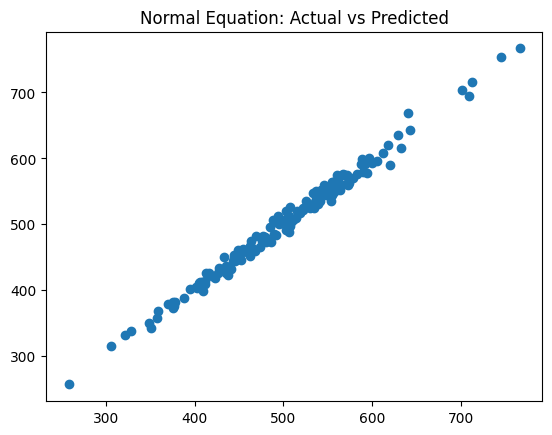

In [ ]:
X_test_np=X_test.to_numpy()
y_test_np=y_test.to_numpy()

ones=np.ones((X_test_np.shape[0], 1))
X_test_np=np.hstack((ones, X_test_np))

y_pred_ne = X_test_np @ theta_best
plt.scatter(y_test_np, y_pred_ne)
plt.title("Normal Equation: Actual vs Predicted")
plt.show()

In [ ]:
print("MAE:",  metrics.mean_absolute_error(y_test_np,y_pred_ne))
print("MSE:",  metrics.mean_squared_error(y_test_np,y_pred_ne))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test_np, y_pred_ne)))
print("R^2:", metrics.r2_score(y_test_np, y_pred_ne))

MAE: 7.228148653457611
MSE: 79.81305165154073
RMSE: 8.933815067010327
R^2: 0.9890046246740454


### What is the limitation of using the Normal equation for regression?
The limitation of using the Normal equation for regression is that we need to compute the inverse of a matrix. This can easily become computationally expensive when the number of features is large. There also may be some issues where the matrix may not be invertible and we cannot compute the Normal Equation. This is why we use Gradient Descent for larger datasets to avoid computing inverse.

##Batch Gradient

In [ ]:
import numpy as np

#cost
cost_list=[]

X_train_scaled_np = X_train_scaled
y_train_np = y_train.to_numpy().reshape(-1, 1)

ones = np.ones((X_train_scaled_np.shape[0], 1))
X_b = np.hstack((ones, X_train_scaled_np))

m=X_b.shape[0]
n=X_b.shape[1]
theta_gd=np.random.randn(n,1)

eta = 0.001  # learning rate
n_iterations = 3000

for iteration in range(n_iterations):

  gradients = 2/m * X_b.T @ (X_b @ theta_gd - y_train_np)
  theta_gd = theta_gd - eta * gradients

  predictions=X_b @ theta_gd
  errors =predictions- y_train_np


  cost = np.sqrt(np.mean(np.square(errors)))
  cost_list.append(cost)

print("Theta from Gradient Descent:")
print(theta_gd)

Theta from Gradient Descent:
[[4.98492154e+02]
 [2.59654526e+01]
 [3.65782771e+01]
 [2.07670404e-01]
 [6.00847733e+01]]


The theta values we got from performing Batch Gradient Descent are almost exactly the same values we got from performing sklearn's linear regression. This means that our algorithm converged successfully and found the global minimum.

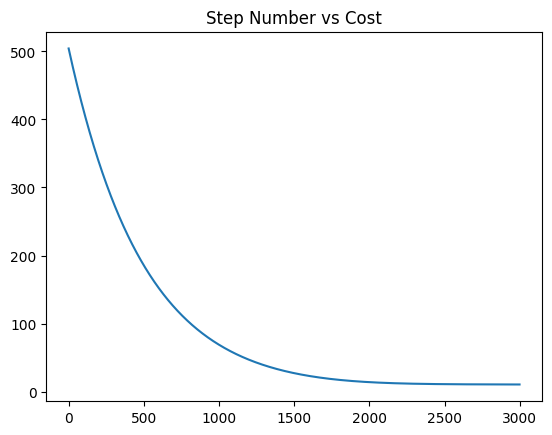

In [ ]:
plt.plot(range(n_iterations), cost_list)
plt.title("Step Number vs Cost")
plt.show()

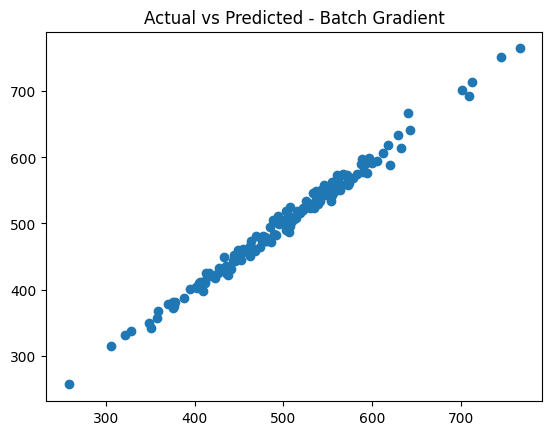

In [ ]:
X_test_scaled_np = X_test_scaled


ones_test = np.ones((X_test_scaled_np.shape[0], 1))
X_test_b = np.hstack((ones_test, X_test_scaled_np))


y_pred_gd = X_test_b @ theta_gd
plt.scatter(y_test, y_pred_gd)
plt.title("Actual vs Predicted - Batch Gradient")
plt.show()

In [ ]:
print("MAE:", metrics.mean_absolute_error(y_test, y_pred_gd))
print("MSE:", metrics.mean_squared_error(y_test, y_pred_gd))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred_gd)))
print("R^2:", metrics.r2_score(y_test, y_pred_gd))

MAE: 7.179012823701214
MSE: 79.7622050618877
RMSE: 8.930968875877225
R^2: 0.989011629510043


###Short Question: How do derivatives help in the process of gradient descent?

Batch Gradient Descent uses derivates to measure the rate of change of the cost function while keeping the model parameters in mind. The partial derivatives are used to compute the global minimum and by moving the opposite way from the gradient we minimize the cost function.

###Short Question: What are the benefits and the limitations of using batch gradient descent?

Benefit:
We can use Batch Gradient is more computationally effifecnt that the normal equation when dealing with a large number of features. Normal Equation required a inverse for a matrix which we've established becomes very expensive as the number of features increases which is why BGD is better for datasets with large features.

Limitations
Batch Gradient Descent can become computationally expensive when we get to larger datasets due to needjing to process all training sample for every iteration. This is why we use Mini-batch gradient or Stocastic Gradient Descent. We also have to be super careful when tuning the learning rate to make sure we get to the proper convergence and avoid overshooting the minimum.

###7. Stochastic Gradient Descent

In [ ]:
n_epochs = 800
t0, t1 = 5, 50

def learning_schedule(t):
    return t0 / (t + t1)

theta_sgd = np.random.randn(n,1)
cost_list_sgd = []
epoch_list = []

for epoch in range(n_epochs):
    for i in range(m):

        random_index = np.random.randint(m)
        xi = X_b[random_index:random_index+1]
        yi = y_train_np[random_index:random_index+1]

        gradients = 2 * xi.T.dot(xi.dot(theta_sgd) - yi)

        eta = learning_schedule(epoch * m + i)
        theta_sgd = theta_sgd - eta * gradients

    predictions = X_b.dot(theta_sgd)
    cost = np.mean((y_train_np - predictions)**2)

    cost_list_sgd.append(cost)
    epoch_list.append(epoch)

print("Theta from Stochastic Gradient Descent:")
print(theta_sgd)

Theta from Stochastic Gradient Descent:
[[4.99699833e+02]
 [2.60410141e+01]
 [3.66230505e+01]
 [2.22900536e-01]
 [6.01947902e+01]]


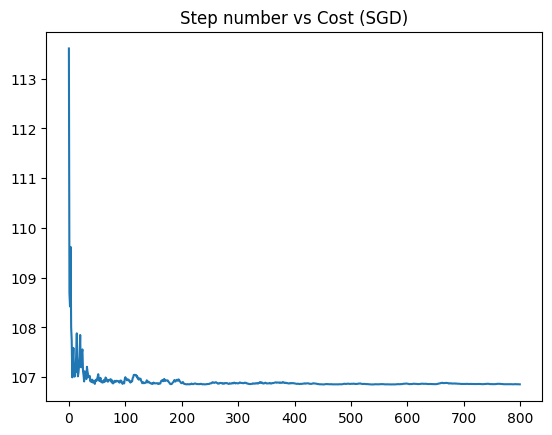

In [ ]:
plt.plot(epoch_list, cost_list_sgd)
plt.title("Step number vs Cost (SGD)")
plt.show()

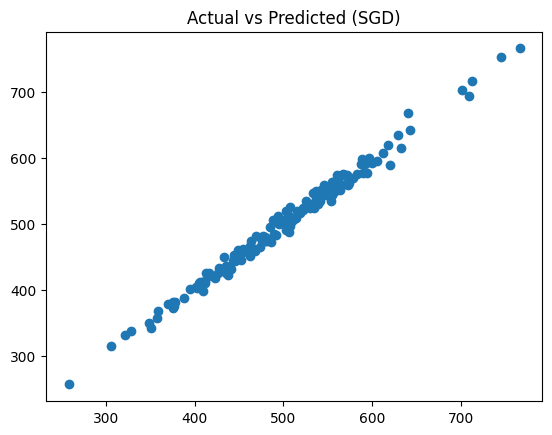

In [ ]:
X_test_scaled_np = X_test_scaled

ones_test = np.ones((X_test_scaled_np.shape[0], 1))
X_test_b = np.hstack((ones_test, X_test_scaled_np))

y_pred_sgd = X_test_b @ theta_sgd
plt.scatter(y_test, y_pred_sgd)
plt.title("Actual vs Predicted (SGD)")
plt.show()

In [ ]:
from sklearn import metrics

print("MAE:", metrics.mean_absolute_error(y_test, y_pred_sgd))
print("MSE:", metrics.mean_squared_error(y_test, y_pred_sgd))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred_sgd)))
print("R^2:", metrics.r2_score(y_test, y_pred_sgd))

MAE: 7.2277973145289645
MSE: 79.78286488836657
RMSE: 8.932125440698119
R^2: 0.9890087833270991


###Short Question: What are the benefits and the limitations of using Stochastic gradient descent?

the benefits of the Stochastic Gradient Descent are that SGD is computationally efficient for larger datasets as it updates the model paramters using one training sample at a time rather the whole dataset (like in Batch Gradient Descent). By running one sample at a time we can process large datasets quickly. SGD can also escape local minima thrugh the randomness of the jumps it performs which lead to better results.

The limitations of SGD is that its very easy to get lots of noise in the dataset due to being based off of one training sample at a time. This means the cost function will flucates instead of show as a smooth decreasing curve like it did in Batch Gradient Descent. This also means that it may take longer to converge. We have to be careful with picking the learning rate and other hyperparameters to ensure proper convergence.

##SGDRegressor from sklearn

In [ ]:
from sklearn.linear_model import SGDRegressor

sgd = SGDRegressor(
    max_iter=5000,
    tol=1e-4,
    eta0=0.01,
    learning_rate='invscaling',
    random_state=101
)

sgd.fit(X_train_scaled, y_train)
print("Intercept:", sgd.intercept_)
print("Coefficients:", sgd.coef_)

Intercept: [499.7088081]
Coefficients: [26.03940156 36.68391314  0.15375466 60.22221299]


These value are very close to the values we attained from the sklearn model from before. If there is any differences, they come from the way we did the calculation. This means that SGDregressor sucessfully converged to the best solution

In [ ]:
y_pred_sgdr =sgd.predict(X_test_scaled)

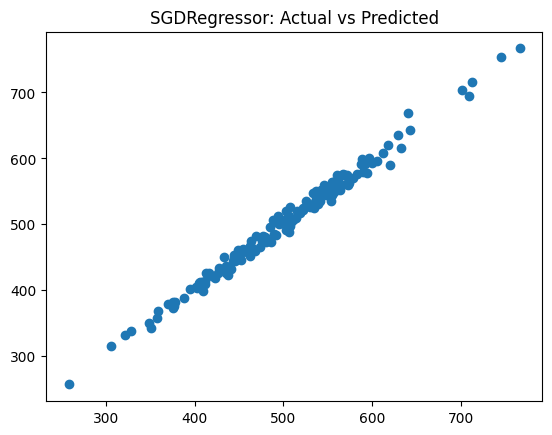

In [ ]:
plt.scatter(y_test, y_pred_sgdr)
plt.title("SGDRegressor: Actual vs Predicted")
plt.show()

In [ ]:
print("MAE:", metrics.mean_absolute_error(y_test, y_pred_sgdr))
print("MSE:", metrics.mean_squared_error(y_test, y_pred_sgdr))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred_sgdr)))
print("R^2:", metrics.r2_score(y_test, y_pred_sgdr))

MAE: 7.226282213955633
MSE: 79.79745058864297
RMSE: 8.932941877603536
R^2: 0.9890067739408445


###Briefly explain how mini-batch can overcome the limitations of Batch gradient descent and SGD.

Mini-Batch Gradient Descent can overcome the limitations set by Batch Gradient Descent (BGD) and Stochastic Gradient Descent (SGD) by combining the advantages of both GD and SGD, such as processing small subsets of data at each iteration. We do this to avoid the issue with BGD, where large datasets can become computationally expensive to process. By performing Mini-Batch Gradient Descent, we split the data into subsets, which allows computation to be less since we process the data in batches rather than as a whole. Mini-Batch Gradient Descent also provides smoother and more stable convergence by updating parameters using multiple samples, unlike SGD, which updates parameters one sample at a time (this can cause a lot of noise). Mini-Batch acts as a balance between the two techniques.

##Polynomial of degree 2

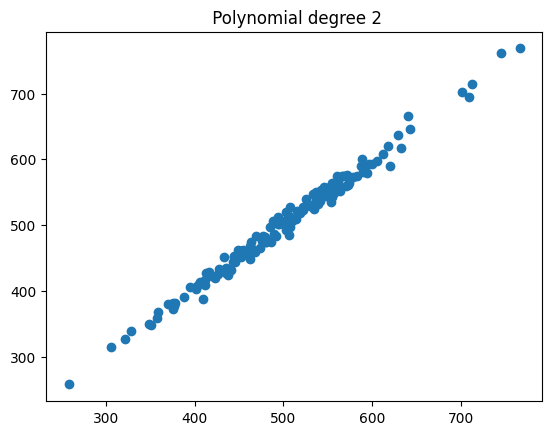

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

poly=PolynomialFeatures(degree = 2)

X_train_poly=poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

#Use linearRegression on the new polynomial features
poly_model=LinearRegression()
poly_model.fit(X_train_poly,y_train)

#Predict for test set
y_pred_poly=poly_model.predict(X_test_poly)

#scatter
plt.scatter(y_test, y_pred_poly)
plt.title (" Polynomial degree 2")
plt.show()


In [ ]:
#quick check
print(X_train_scaled.shape)
print(X_train_poly.shape)

(350, 4)
(350, 15)


In [ ]:
print("MAE:",  metrics.mean_absolute_error(y_test,y_pred_poly))
print("MSE:",  metrics.mean_squared_error(y_test,y_pred_poly))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred_poly)))
print("R^2:", metrics.r2_score(y_test,y_pred_poly))

MAE: 7.432195703827274
MSE: 85.34745505512008
RMSE: 9.238368636026605
R^2: 0.9882421824247091


##Polynomial of degree 3

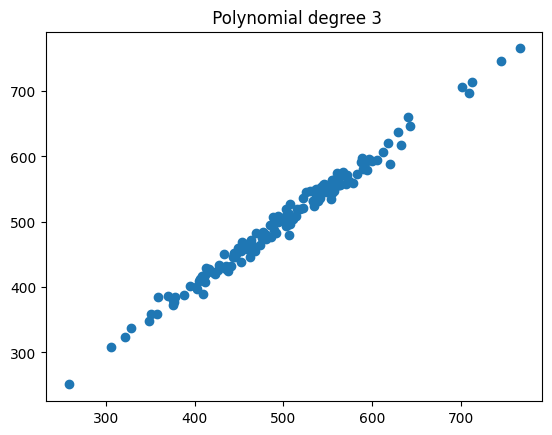

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

poly3=PolynomialFeatures(degree = 3)

X_train_poly3=poly3.fit_transform(X_train_scaled)
X_test_poly3 = poly3.transform(X_test_scaled)

#Use linearRegression on the new polynomial features
poly_model3=LinearRegression()
poly_model3.fit(X_train_poly3,y_train)

#Predict for test set
y_pred_poly3=poly_model3.predict(X_test_poly3)

#scatter
plt.scatter(y_test, y_pred_poly3)
plt.title (" Polynomial degree 3")
plt.show()


In [ ]:
print(X_train_scaled.shape)
print(X_train_poly3.shape)

(350, 4)
(350, 35)


In [ ]:
print("MAE:",  metrics.mean_absolute_error(y_test,y_pred_poly3))
print("MSE:",  metrics.mean_squared_error(y_test,y_pred_poly3))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred_poly3)))
print("R^2:", metrics.r2_score(y_test,y_pred_poly3))

MAE: 7.695801008025575
MSE: 94.96886930851961
RMSE: 9.745197243181876
R^2: 0.9869166966965791


###12. Learning Curve

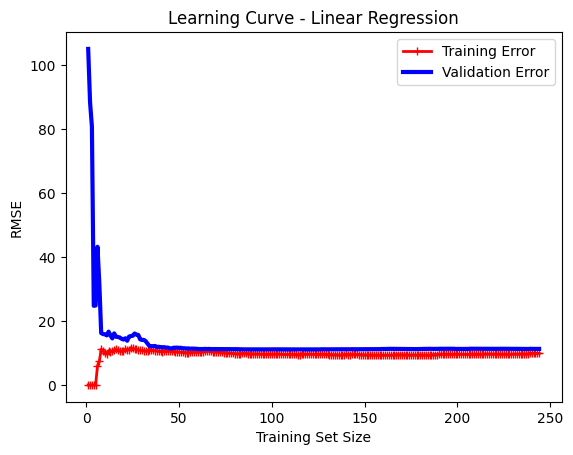

In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

def plot_learning_curves(model, X, y, title):

    X_train_lc, X_val_lc, y_train_lc, y_val_lc = train_test_split(X, y, test_size=0.3, random_state=101)

    train_errors = []
    val_errors = []
    train_sizes=[]

    for m in range(1, len(X_train_lc)):
        model.fit(X_train_lc[:m], y_train_lc[:m])

        y_train_predict = model.predict(X_train_lc[:m])
        y_val_predict = model.predict(X_val_lc)

        train_errors.append(mean_squared_error(y_train_lc[:m], y_train_predict))
        val_errors.append(mean_squared_error(y_val_lc, y_val_predict))
        train_sizes.append(m)

    plt.plot(train_sizes, np.sqrt(train_errors), "r-+", linewidth=2, label="Training Error")
    plt.plot(train_sizes, np.sqrt(val_errors), "b-", linewidth=3, label="Validation Error")
    plt.xlabel("Training Set Size")
    plt.ylabel("RMSE")
    plt.title(title)

    plt.legend()
    plt.show()
lin_reg = LinearRegression()
plot_learning_curves(lin_reg, X_train_scaled, y_train, "Learning Curve - Linear Regression")

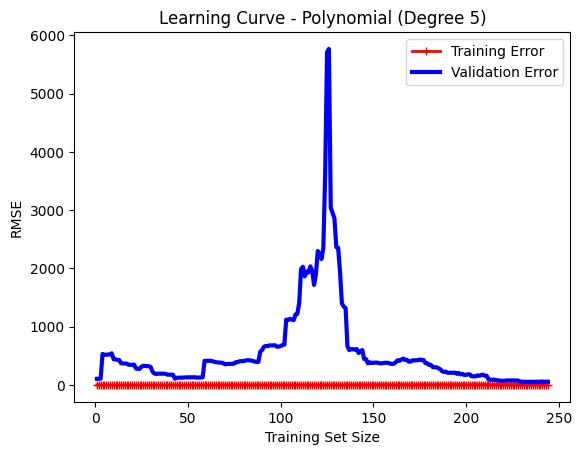

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

polynomial_regression = Pipeline([
    ("poly_features", PolynomialFeatures(degree=5, include_bias=False)),
    ("lin_reg", LinearRegression())
])

plot_learning_curves(polynomial_regression, X_train_scaled, y_train, "Learning Curve - Polynomial (Degree 5)")

###A little zoomed in plots

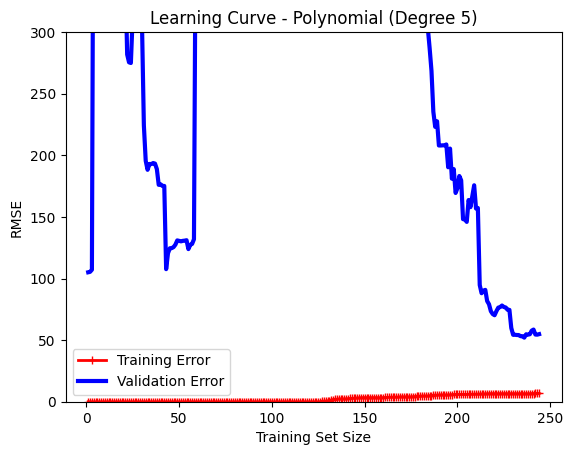

In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

def plot_learning_curves(model, X, y, title):

    X_train_lc, X_val_lc, y_train_lc, y_val_lc = train_test_split(X, y, test_size=0.3, random_state=101)

    train_errors = []
    val_errors = []
    train_sizes=[]

    for m in range(1, len(X_train_lc)):
        model.fit(X_train_lc[:m], y_train_lc[:m])

        y_train_predict = model.predict(X_train_lc[:m])
        y_val_predict = model.predict(X_val_lc)

        train_errors.append(mean_squared_error(y_train_lc[:m], y_train_predict))
        val_errors.append(mean_squared_error(y_val_lc, y_val_predict))
        train_sizes.append(m)

    plt.plot(train_sizes, np.sqrt(train_errors), "r-+", linewidth=2, label="Training Error")
    plt.plot(train_sizes, np.sqrt(val_errors), "b-", linewidth=3, label="Validation Error")

    plt.xlabel("Training Set Size")
    plt.ylabel("RMSE")
    plt.title(title)
    plt.ylim(0, 300)
    plt.legend()
    plt.show()


plot_learning_curves(polynomial_regression, X_train_scaled, y_train, "Learning Curve - Polynomial (Degree 5)")


###Interpret the result

The learning curve I got for linear regression shows that our validation error starts high while the training size is small. This is due to the model not having enough data to learn the patterns of the data, as soon as the training set size increases the models learn the patterns which causes the validation error to decrease very rapidly and stabalize. The training error inclreases very slightoy as we add more data to the model and eventually the traingn and validation error converge and remian close to each other. This learning curve shows that the model isnt overfitting significantly and since the errors stabalize at a similar value it might mean that there might be some bias and isn't able to capture the complexity of the data.

In the learning curve I got Polynomial degree 5 we can see that we have very low training error which increases very slightly as we add more data. We see that the validation error is very high and flucatautes a little which indicated the model is overfitting the training data and generalizing pooly to validation error. This learning curve captures more of the noise in the training data. The gap between training and validation error curves might suggest that there high variance in the model due to how much more complex the model is.

###Explain the purpose of regularization

  We use regularization to help reduce overfitting in Machine Learning. If a model become too complex it may do really well on training data but generalizes poorly to unseen data, when this happens we can use regularization to help simplify the model. This works by constraining a model to make it simpler to reduce the risk of overfitting. By using regulairzation we reduce the risk of overfitting and we get better predictive performance.

In [ ]:
poly3 = PolynomialFeatures(degree=3)

X_train_poly3 = poly3.fit_transform(X_train_scaled)
X_test_poly3 = poly3.transform(X_test_scaled)

##Ridge Regression

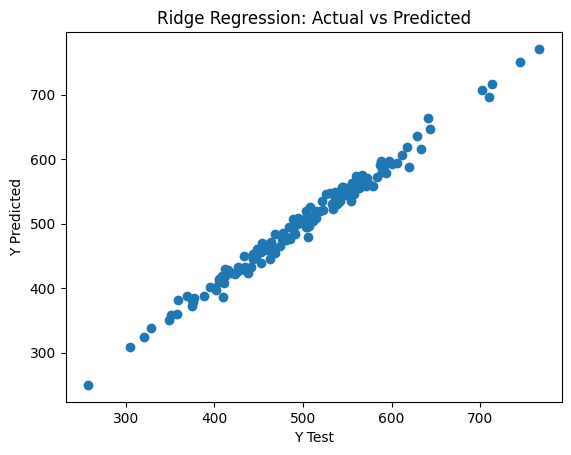

MAE: 7.847034337711345
MSE: 97.45775870457535
RMSE: 9.87206962620176
R^2: 0.9865738170235414


In [ ]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train_poly3, y_train)

y_pred_ridge = ridge_model.predict(X_test_poly3)

plt.scatter(y_test, y_pred_ridge)
plt.title("Ridge Regression: Actual vs Predicted")
plt.xlabel("Y Test")
plt.ylabel("Y Predicted")
plt.show()

print("MAE:", metrics.mean_absolute_error(y_test, y_pred_ridge))
print("MSE:", metrics.mean_squared_error(y_test, y_pred_ridge))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred_ridge)))
print("R^2:", metrics.r2_score(y_test, y_pred_ridge))

##SGDRegressor  for Ridge

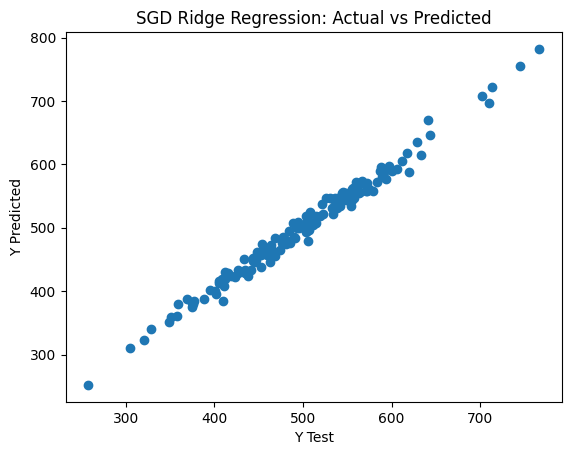

MAE: 8.248988909382698
MSE: 107.79593037106099
RMSE: 10.382481898422023
R^2: 0.985149587836648


In [ ]:
from sklearn.linear_model import SGDRegressor

sgd_ridge = SGDRegressor(penalty='l2', max_iter=5000, eta0=0.001, random_state=101)

sgd_ridge.fit(X_train_poly3, y_train)

y_pred_sgd_ridge = sgd_ridge.predict(X_test_poly3)

plt.scatter(y_test, y_pred_sgd_ridge)
plt.title("SGD Ridge Regression: Actual vs Predicted")
plt.xlabel("Y Test")
plt.ylabel("Y Predicted")
plt.show()

print("MAE:", metrics.mean_absolute_error(y_test, y_pred_sgd_ridge))
print("MSE:", metrics.mean_squared_error(y_test, y_pred_sgd_ridge))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred_sgd_ridge)))
print("R^2:", metrics.r2_score(y_test, y_pred_sgd_ridge))

##Lasso Regression

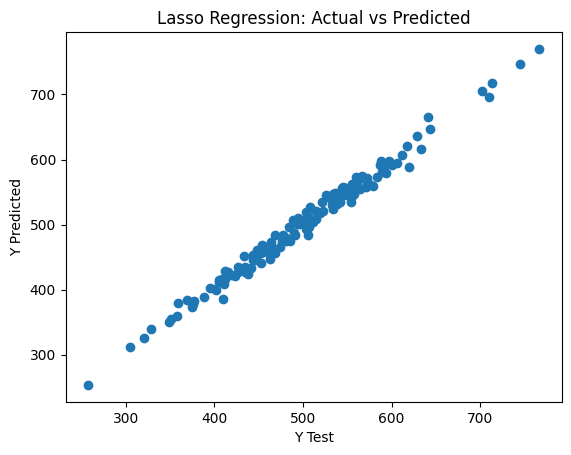

MAE: 7.682772839473522
MSE: 93.19911225524152
RMSE: 9.653968730798827
R^2: 0.9871605057307394


In [ ]:
from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha=0.1)

lasso_model.fit(X_train_poly3, y_train)

y_pred_lasso = lasso_model.predict(X_test_poly3)

plt.scatter(y_test, y_pred_lasso)
plt.title("Lasso Regression: Actual vs Predicted")
plt.xlabel("Y Test")
plt.ylabel("Y Predicted")
plt.show()

print("MAE:", metrics.mean_absolute_error(y_test, y_pred_lasso))
print("MSE:", metrics.mean_squared_error(y_test, y_pred_lasso))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred_lasso)))
print("R^2:", metrics.r2_score(y_test, y_pred_lasso))

###How Lasso perform the regularization and how does that affect the thetas?

Lasso Regression uses L1 regularization to discourage the model from assigning large value to the coefficants. This results in the theta values to become very small and almost exactly zero. And when theta becomes Zero, it essentially means we have removed the feature from our model completely. Lasso helps with overfitting by using this penalty term to perfrom automatic feature selection so that only the most important features are kept while the non-important features are removed to reduce noise.

###Elastic Net

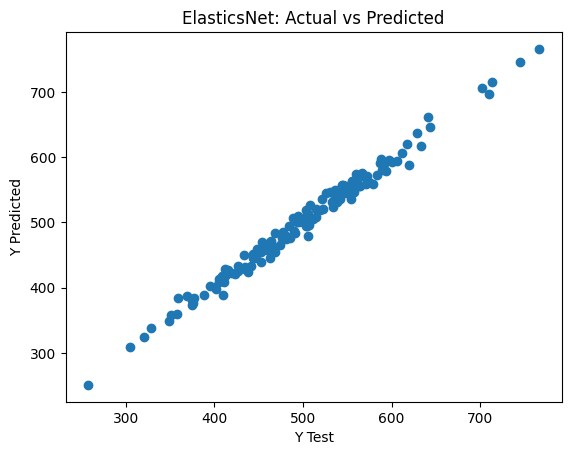

MAE: 7.711400167986074
MSE: 95.28185221743924
RMSE: 9.761242350102739
R^2: 0.9868735788795935


In [ ]:
from sklearn.linear_model import ElasticNet

elastic_net = ElasticNet(alpha=0.001, l1_ratio=0.5)
elastic_net.fit(X_train_poly3, y_train)
y_pred_elastic = elastic_net.predict(X_test_poly3)

plt.scatter(y_test, y_pred_elastic)
plt.title("ElasticsNet: Actual vs Predicted")
plt.xlabel("Y Test")
plt.ylabel("Y Predicted")
plt.show()

print("MAE:", metrics.mean_absolute_error(y_test, y_pred_elastic))
print("MSE:", metrics.mean_squared_error(y_test, y_pred_elastic))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred_elastic)))
print("R^2:", metrics.r2_score(y_test, y_pred_elastic))

###How ElasticNet different compared to Lasso and RIDGE perform the regularization and how does that affect the thetas?

ElasticNet combines the methods from Lasso and Ridge Regression to shrink coefficants to control overfitting and perform feature selection. ElasticNet uses both L1 and L2 penalties together which helps the theta values to get smaller and remove the non-important features. Ridge regression uses the L2 penalty while Lasso regression uses L1 penalty

In [ ]:
new_customer = [[35.49726772511229,12.655651149166752,39.57766801952616,4.082620632952961]]

new_customer_scaled=scaler.transform(new_customer)
prediction=lr.predict(new_customer_scaled)
print("Predicted yearly amount spent:", prediction[0])

Predicted yearly amount spent: 526.0382699269552


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
